# Task 1: Exploring and Visualizing the Iris Dataset

**DevelopersHub Corporation — AI/ML Engineering Internship**

## Objective
Load, inspect, and visualize the Iris dataset to understand feature distributions and relationships.

## Dataset
Iris Dataset (150 samples, 4 features, 3 species) — loaded via Seaborn.


In [1]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
%matplotlib inline


## 1. Load the Dataset


In [2]:
# Load Iris via seaborn (equivalent to CSV)
iris = sns.load_dataset('iris')
df = iris.copy()

print('Shape:', df.shape)
print('\nColumn names:', list(df.columns))
print('\nFirst 5 rows:')
df.head()


Shape: (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Data Inspection


In [3]:
df.info()
print('\n' + '='*60 + '\n')
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB




,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Check for missing values and species balance
print('Missing values per column:\n', df.isnull().sum())
print('\nSpecies counts:\n', df['species'].value_counts())


Missing values per column:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Species counts:
 species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


## 3. Visualizations


### 3.1 Scatter plots — feature relationships


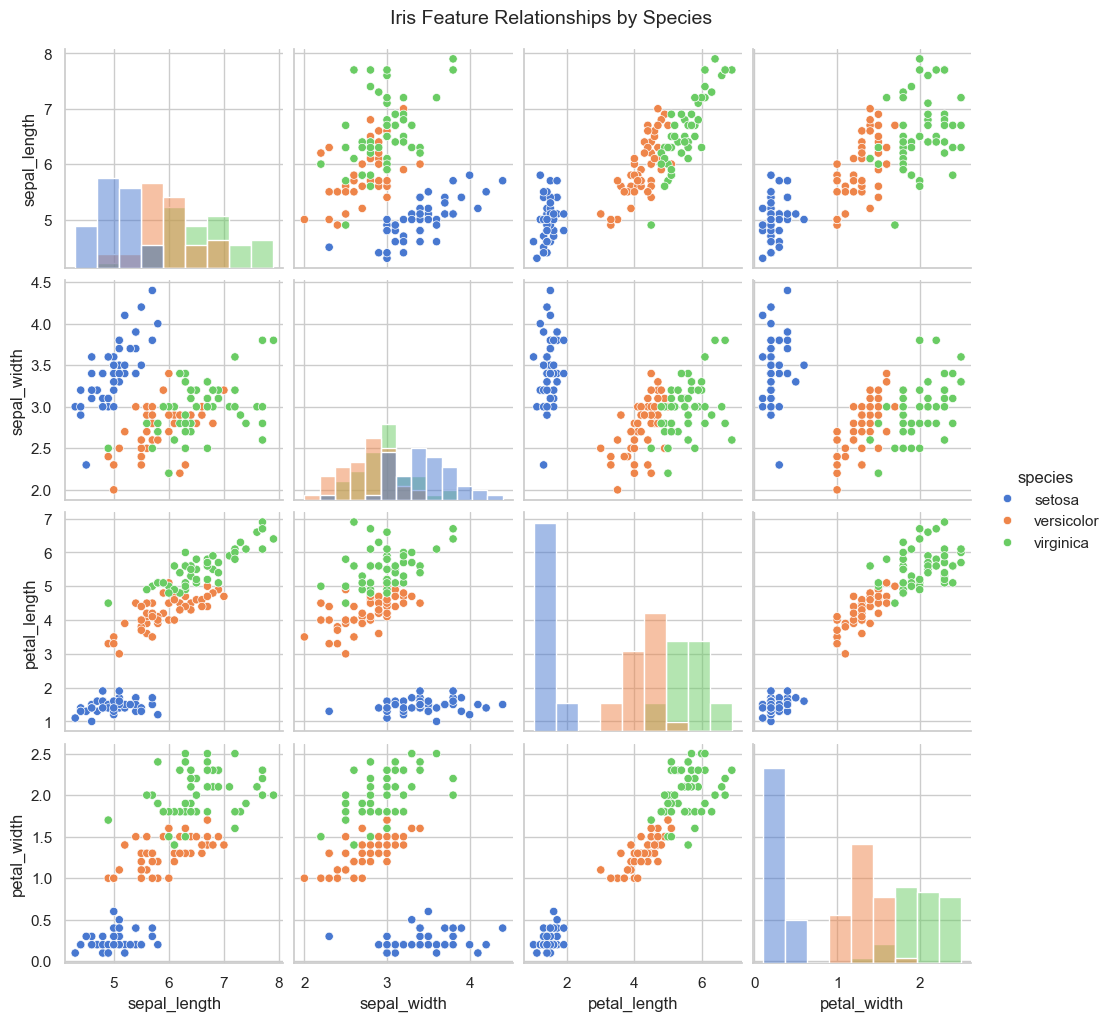

In [5]:
# Pairplot shows scatter relationships and species separation
g = sns.pairplot(df, hue='species', diag_kind='hist', corner=False)
g.fig.suptitle('Iris Feature Relationships by Species', y=1.02, fontsize=14)
plt.show()


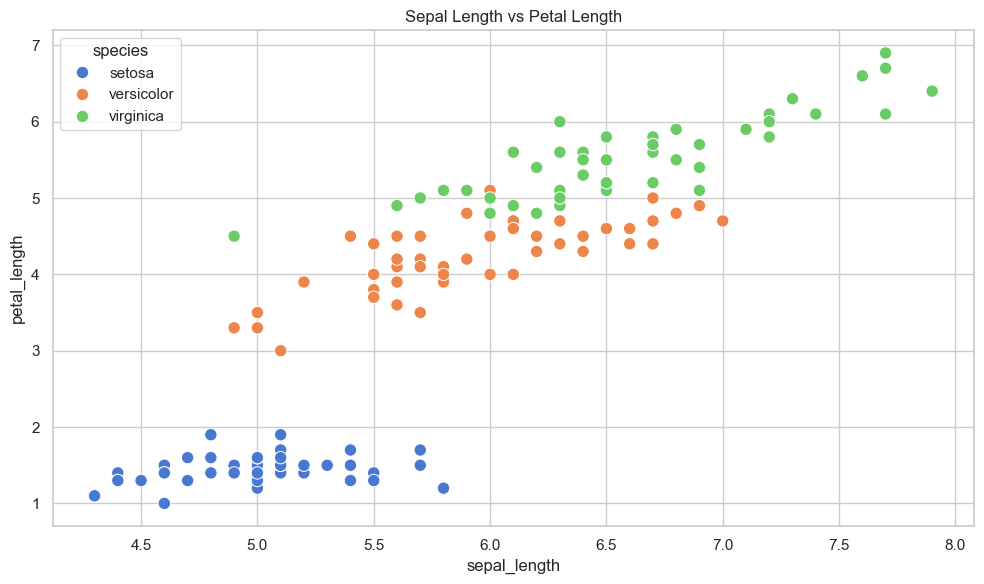

In [6]:
# Focused scatter: sepal length vs petal length
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='sepal_length', y='petal_length', hue='species', s=80, ax=ax)
ax.set_title('Sepal Length vs Petal Length')
plt.tight_layout()
plt.show()


### 3.2 Histograms — value distributions


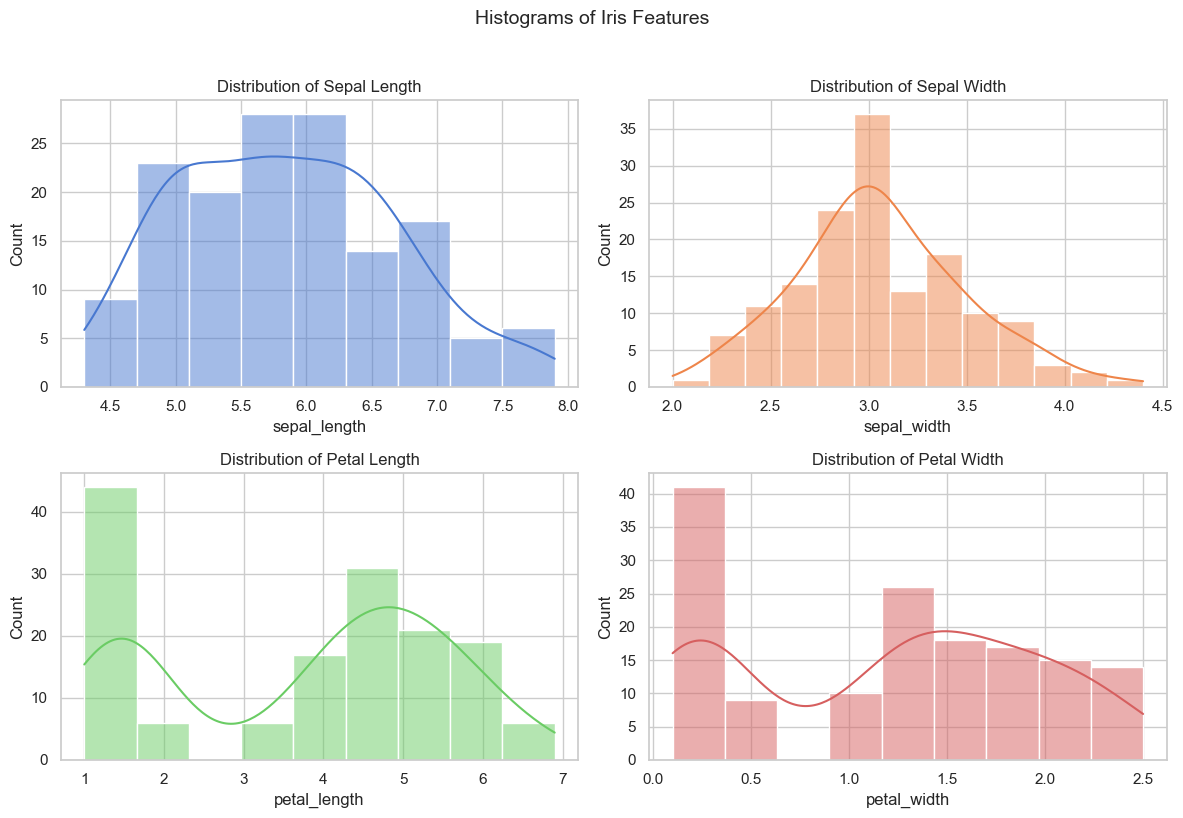

In [7]:
feature_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color=sns.color_palette()[i])
    axes[i].set_title(f'Distribution of {col.replace("_", " ").title()}')

fig.suptitle('Histograms of Iris Features', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3.3 Box plots — outliers


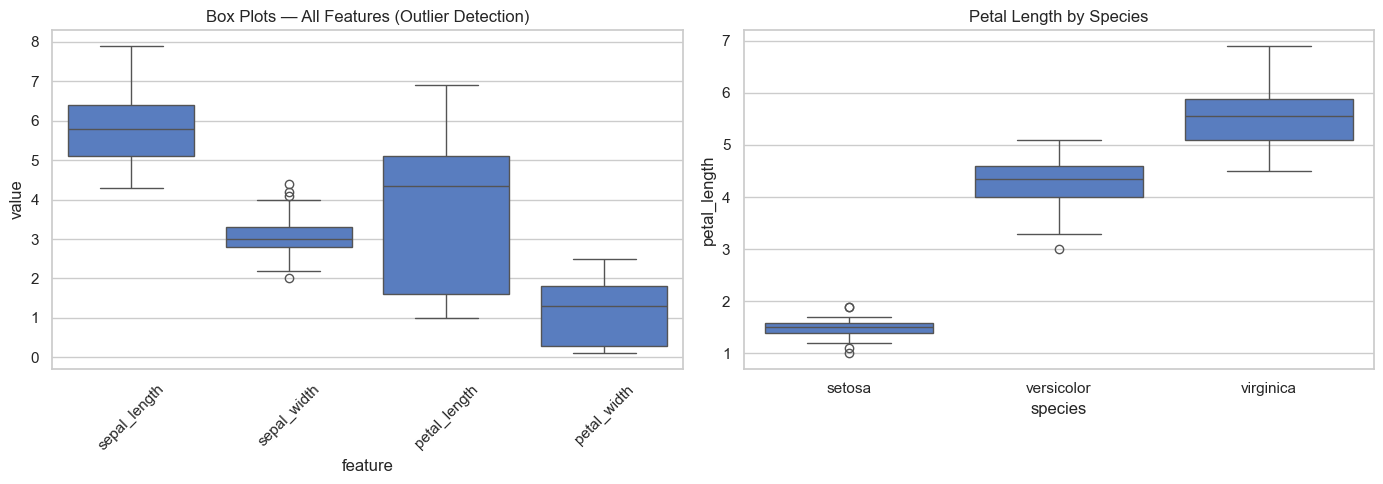

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot by feature (melted)
melted = df.melt(id_vars='species', value_vars=feature_cols, var_name='feature', value_name='value')
sns.boxplot(data=melted, x='feature', y='value', ax=axes[0])
axes[0].set_title('Box Plots — All Features (Outlier Detection)')
axes[0].tick_params(axis='x', rotation=45)

# Box plot per species for petal length
sns.boxplot(data=df, x='species', y='petal_length', ax=axes[1])
axes[1].set_title('Petal Length by Species')

plt.tight_layout()
plt.show()


## 4. Key Insights

- **Shape:** 150 rows × 5 columns (4 numeric features + species label).
- **No missing values** in the standard Iris dataset.
- **Petal length and petal width** show the clearest separation between species.
- **Setosa** is linearly separable from versicolor and virginica on petal features.
- Box plots show few extreme outliers; Iris is a clean benchmark dataset for classification and visualization practice.
